In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error as MAPE
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
import pickle

import os
import logging

In [4]:
# In Python, calling logging.getLogger(name) multiple times with the exact same name will neither overwrite the logger nor create multiple copies
# ; instead, it will always return a reference to the exact same singleton object. 

# However, how you configure that logger can cause an unexpected side effect: it will create multiple copies of your log outputs (duplicated logs)
# if you keep adding handlers to it

logger_name = '5_Model_Training_Evaluation'

def create_logger_handler(log_folder, logger_name):
    # Ensure log directory exists
    log_dir = log_folder
    os.makedirs(log_dir, exist_ok=True)

    # logging configuration
    logger = logging.getLogger(logger_name)
    logger.setLevel('DEBUG')


    # This is to print at console level
    console_handler = logging.StreamHandler()
    console_handler.setLevel('DEBUG')

  # This is to print in log file
    file_path = os.path.join(log_dir, logger_name+'.log')
    file_handler = logging.FileHandler(file_path)
    file_handler.setLevel('DEBUG')

    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    console_handler.setFormatter(formatter)
    file_handler.setFormatter(formatter)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)

    return logger

logger = create_logger_handler('../logs', logger_name)

# If we want to diable the logger
# logging.getLogger("Data_Ingestion").disabled = True

# If we disable logger then we can again enable it by just triggering above cell again. Logger will automatically enable it.

In [3]:
# If we have run above code multiple times then we will have multiple handlers which results in printing same output twice/thrice
# We can remove active handlers but we can't remove logger

def close_remove_active_handler(logger_name):

    # active log handlers
    logger = logging.getLogger(logger_name)
    print(f'Active handlers for logger- {logger_name} is -', len(logger.handlers))

    for handler in logger.handlers[:]:
        handler.close()
        logger.removeHandler(handler)

    print(f'Active handlers for logger- {logger_name} is -', len(logger.handlers))

close_remove_active_handler(logger_name)


Active handlers for logger- 5_Model_Training_Evaluation is - 2
Active handlers for logger- 5_Model_Training_Evaluation is - 0


In [5]:
df = pd.read_csv('../data/Train_Test/Train_Data.csv')
print(df.shape)

df.head()

(427, 4)


,Wage,Education,Experience,Age
0,7380,14,15,35
1,6360,12,9,27
2,6000,16,8,30
3,7500,11,3,20
4,3750,12,9,27


In [7]:
import statsmodels.api as sm
from statsmodels.api import OLS
from statsmodels.api import add_constant

x_train = df.iloc[:, 1:]
y_train = df.iloc[:, :1]

# Adding constant to x_train and x_test
x_train_constant = add_constant(x_train)

model = OLS(endog = y_train, exog = x_train_constant).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Wage   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     41.63
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           1.37e-23
Time:                        18:49:15   Log-Likelihood:                -4190.2
No. Observations:                 427   AIC:                             8388.
Df Residuals:                     423   BIC:                             8405.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4977.7283   6827.874     -0.729      0.4

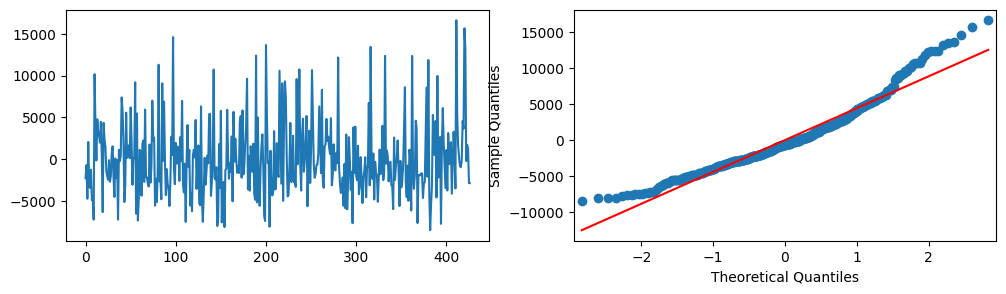

In [8]:
f, axes = plt.subplots(1, 2, figsize=(12, 3), sharex=False, sharey=False)

# This is shows residuals have constant variance and no trend/seasonality. This satisfy condition of homoscedasticity.
sns.lineplot(model.resid, ax=axes[0])

# This shows if residual are normally distributed
sm.qqplot(model.resid, line='s', ax = axes[1])

# Adjust layout to prevent overlapping titles/labels
# plt.tight_layout()
plt.show()

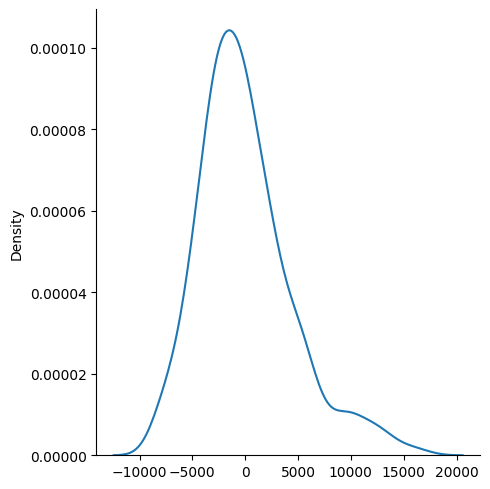

In [9]:
# This shows if residual are normally distributed
sns.displot(model.resid, kind='kde')
plt.show()

In [10]:
df_summary = pd.DataFrame({'Coeficient':model.params, 'Std Err': model.bse,
                           't-value': model.tvalues, 'p-value': model.pvalues,
                           'R-squared': model.rsquared, 'Adj R-squared': model.rsquared_adj})
df_summary.rename(index={'const': 'Intercept'}, inplace=True)                           
df_summary.head()

,Coeficient,Std Err,t-value,p-value,R-squared,Adj R-squared
Intercept,-4977.728328,6827.874237,-0.729030,0.466386,0.227929,0.222453
Education,990.660898,1115.575807,0.888027,0.375031,0.227929,0.222453
Experience,163.520550,1116.358924,0.146477,0.883615,0.227929,0.222453
Age,-48.491447,1115.169123,-0.043483,0.965337,0.227929,0.222453


In [11]:
# This is the format in which we would want to save Intercept/Coeficient and then share with other team
model_summary = pd.DataFrame(model.params)
model_summary = model_summary.transpose()
model_summary.rename(columns={'const': 'Intercept'}, inplace=True)
model_summary.head()

,Intercept,Education,Experience,Age
0,-4977.728328,990.660898,163.52055,-48.491447


In [12]:
# Saving model

with open('../models/Regression.pkl', 'wb') as file:
    pickle.dump(model, file)

In [34]:
def load_test_data(path):
    """ Loading test data """

    try:
        df = pd.read_csv(path)
        logger.debug('Test data has loaded successfully')
        x_test = df.iloc[:, 1:]
        y_test = df.iloc[:, :1]
        logger.debug('Successfully divided test data into X_test, y_test')
        
        return df, x_test, y_test

    except Exception as e:
        logger.debug("Loading test data has failed - %s", e)
        raise


def pre_processing(test_data):

    """ Data pre-processing on test data"""
    
    try:
        x_test_constant = add_constant(test_data)
        logger.debug('Constant has been added to x_test')

        return x_test_constant
    
    except Exception as e:
        logger.debug('x_test pre-processing has failed - %s', e)
        raise


def prediction(model, data):
    """ This function is predict on inference data"""

    try:
        prediction = model.predict(data).tolist()
        logger.debug('Prediction has been generated successfully')

        return prediction
    
    except Exception as e:
        logger.debug('Unexpected error in generating prediction - %s', e)


In [35]:
test_data, x_test, y_test = load_test_data('../data/Train_Test/Test_Data.csv')

test_processed_data = pre_processing(x_test)

prediction = prediction(model, test_processed_data)

df_prediction = pd.DataFrame({'y_test':y_test['Wage'], 'y_pred':np.round(prediction,2)})
MAPE(df_prediction['y_test'], df_prediction['y_pred'] )

2026-06-08 19:12:35,952 - 5_Model_Training_Evaluation - DEBUG - Test data has loaded successfully
2026-06-08 19:12:35,955 - 5_Model_Training_Evaluation - DEBUG - Successfully divided test data into X_test, y_test
2026-06-08 19:12:35,963 - 5_Model_Training_Evaluation - DEBUG - Constant has been added to x_test
2026-06-08 19:12:35,971 - 5_Model_Training_Evaluation - DEBUG - Prediction has been generated successfully


0.5058851408047947

In [36]:
# wwork on creating train accuracy

# prediction = prediction(model, processed_data)

# df_prediction = pd.DataFrame({'y_test':y_test['Wage'], 'y_pred':np.round(prediction,2)})
# MAPE(df_prediction['y_test'], df_prediction['y_pred'] )